🧮 Assignment: AdaBoost Algorithm using Python

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# -----------------------------------------------------------
# Step 1: Load Dataset
# -----------------------------------------------------------

# Using the built-in Iris dataset
from sklearn.datasets import load_iris
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

print("🔹 First 5 rows of dataset:")
print(df.head())


🔹 First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [3]:
# -----------------------------------------------------------
# Step 2: Split Dataset into Train and Test
# -----------------------------------------------------------

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
# -----------------------------------------------------------
# Step 3: Create and Train AdaBoost Model
# -----------------------------------------------------------

# Using Decision Tree as a weak learner
base_estimator = DecisionTreeClassifier(max_depth=1)
model = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.8, random_state=42)
model.fit(X_train, y_train)

# -----------------------------------------------------------
# Step 4: Make Predictions
# -----------------------------------------------------------

y_pred = model.predict(X_test)

In [5]:
# -----------------------------------------------------------
# Step 5: Evaluate Model Performance
# -----------------------------------------------------------

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n🔹 Confusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("\n🔹 Classification Report:\n", report)


✅ Model Accuracy: 100.00%

🔹 Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

🔹 Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



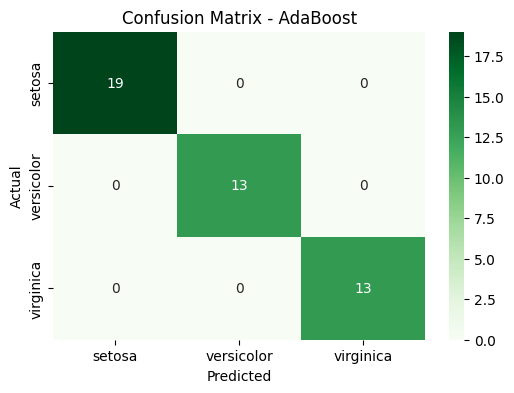

In [6]:

# -----------------------------------------------------------
# Step 6: Visualization
# -----------------------------------------------------------

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - AdaBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()